# Generare strutture cristalline con PyXtal

Questo notebook mostra come usare [`pyxtal`](https://pyxtal.readthedocs.io/) per generare
**strutture cristalline casuali ma simmetricamente valide**, a partire da uno space group
(1-230) e una composizione chimica.

A differenza di `pymatgen`/`ase` (usati nel resto di `dim_red` per leggere/manipolare
strutture *esistenti*, es. quelle scaricate da Materials Project in `dim_red.fetch`),
`pyxtal` genera posizioni atomiche *da zero*, compatibili con le posizioni di Wyckoff dello
space group richiesto.

**Nota:** `pyxtal` non è tra le dipendenze assunte installate da `CLAUDE.md` — va installato
a parte con `pip install pyxtal`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms

from pyxtal import pyxtal
from pyxtal.msg import Comp_CompatibilityError
from pyxtal.symmetry import Group

np.random.seed(0)

## 1. Una struttura casuale per un dato space group

Bisogna specificare: lo **space group** (numero 1-230), gli **elementi chimici**, e
**quanti atomi** di ciascun elemento mettere nella cella unitaria (`numIons`). `pyxtal` li
piazza su posizioni di Wyckoff compatibili con la simmetria richiesta.

Esempio: NaCl (rock salt), space group 225 (*Fm-3m*), 4 Na + 4 Cl per cella.

In [2]:
c = pyxtal()
c.from_random(dim=3, group=225, species=["Na", "Cl"], numIons=[4, 4])
print(c)


------Crystal from random------
Dimension: 3
Composition: Na4Cl4
Group: F m -3 m (225)
  5.8676,   5.8676,   5.8676,  90.0000,  90.0000,  90.0000, cubic
Wyckoff sites:
	Na @ [ 0.0000  0.0000  0.0000], WP [4a] Site [m-3m]
	Cl @ [ 0.5000  0.5000  0.5000], WP [4b] Site [m-3m]


### Conversione verso pymatgen / ASE

Come nel resto di `dim_red`, è comodo lavorare con oggetti ASE `Atoms` o pymatgen
`Structure`.

In [3]:
structure = c.to_pymatgen()
atoms = c.to_ase()

print("pymatgen Structure:")
print(structure)
print("\nASE Atoms:", atoms)

pymatgen Structure:
Full Formula (Na4 Cl4)
Reduced Formula: NaCl
abc   :   5.867612   5.867612   5.867612
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (8)
  #  SP      a     b     c
---  ----  ---  ----  ----
  0  Cl    0.5   0.5   0.5
  1  Cl    0.5  -0    -0
  2  Cl    0     0.5  -0
  3  Cl    0     0     0.5
  4  Na    0     0     0
  5  Na    0     0.5   0.5
  6  Na    0.5  -0     0.5
  7  Na    0.5   0.5  -0

ASE Atoms: Atoms(symbols='Na4Cl4', pbc=True, cell=[[5.867612337078939, 3.5928763336206217e-16, 3.5928763336206217e-16], [0.0, 5.867612337078939, 3.5928763336206217e-16], [0.0, 0.0, 5.867612337078939]])


### Visualizzazione rapida

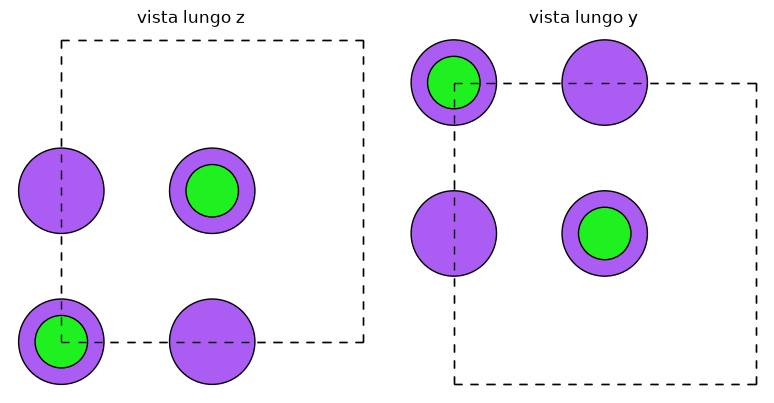

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
plot_atoms(atoms, axes[0], radii=0.5, rotation=("0x,0y,0z"))
plot_atoms(atoms, axes[1], radii=0.5, rotation=("90x,0y,0z"))
axes[0].set_title("vista lungo z")
axes[1].set_title("vista lungo y")
plt.tight_layout()
plt.show()

## 2. Non tutte le composizioni sono compatibili con ogni space group

Le posizioni di Wyckoff di uno space group hanno molteplicità fisse; se il numero di atomi
richiesto non è esprimibile come somma di quelle molteplicità, la generazione fallisce con
`Comp_CompatibilityError`.

In [5]:
try:
    c_bad = pyxtal()
    c_bad.from_random(dim=3, group=225, species=["Na", "Cl"], numIons=[1, 1])
except Comp_CompatibilityError as e:
    print(f"Fallito come atteso: {e}")

# Le molteplicità di Wyckoff del gruppo 225 impongono invece 4, 4 (o multipli)
c_ok = pyxtal()
c_ok.from_random(dim=3, group=225, species=["Na", "Cl"], numIons=[4, 4])
print("OK invece con [4, 4]:")
print(c_ok)

Fallito come atteso: Composition [1 1] not compatible with symmetry 225
OK invece con [4, 4]:

------Crystal from random------
Dimension: 3
Composition: Na4Cl4
Group: F m -3 m (225)
  5.4732,   5.4732,   5.4732,  90.0000,  90.0000,  90.0000, cubic
Wyckoff sites:
	Na @ [ 0.5000  0.5000  0.5000], WP [4b] Site [m-3m]
	Cl @ [ 0.0000  0.0000  0.0000], WP [4a] Site [m-3m]


## 3. Una struttura per ciascuno dei 230 space group

È possibile generare *da zero* una struttura per ognuno dei 230 space group? Sì — a patto di
gestire i fallimenti di compatibilità riprovando con un numero diverso di atomi.

Usiamo un unico elemento (carbonio, come placeholder) e proviamo alcune molteplicità
candidate finché una non funziona.

In [6]:
CANDIDATE_NUM_IONS = [1, 2, 3, 4, 6, 8, 12, 16, 24, 48, 96, 192]


def generate_one_structure(spacegroup, species=("C",), max_count=5):
    """Prova a generare una struttura per `spacegroup`, scorrendo le molteplicità
    candidate finché una risulta compatibile con la simmetria richiesta.
    """
    for n in CANDIDATE_NUM_IONS:
        try:
            crystal = pyxtal()
            crystal.from_random(
                dim=3,
                group=spacegroup,
                species=list(species),
                numIons=[n] * len(species),
                max_count=max_count,
            )
            return crystal
        except Comp_CompatibilityError:
            continue
        except Exception:
            continue
    return None


atoms_list = []
families = []
failed_spacegroups = []

for spacegroup in range(1, 231):
    for attempt in range(10):
        crystal = generate_one_structure(spacegroup)
        if crystal is None:
            failed_spacegroups.append(spacegroup)
            continue
        atoms = crystal.to_ase()
        atoms.info["spacegroup"] = spacegroup
        atoms.info["material_id"] = f"pyxtal-{spacegroup}"
        family = Group(spacegroup).lattice_type.capitalize()
        atoms_list.append(atoms)
        families.append(family)

print(f"Generate {len(atoms_list)}/230 strutture.")
if failed_spacegroups:
    print("Space group falliti:", failed_spacegroups)

Generate 2300/230 strutture.


## 4. Confronto con il resto di `dim_red`

Il dataset sintetico appena generato è nella stessa forma (`List[Atoms]` + etichetta di
famiglia) di quello prodotto da `dim_red.fetch.fetch_structures_by_crystal_system`, quindi
possiamo riusare direttamente le utility del pacchetto -- ad esempio l'istogramma per
spacegroup colorato per famiglia già usato nel report di comparazione delle run
(`dim_red.pipeline.compare.plot_spacegroup_family_histogram`).

/home/seraftu/miniconda3/envs/dmred/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


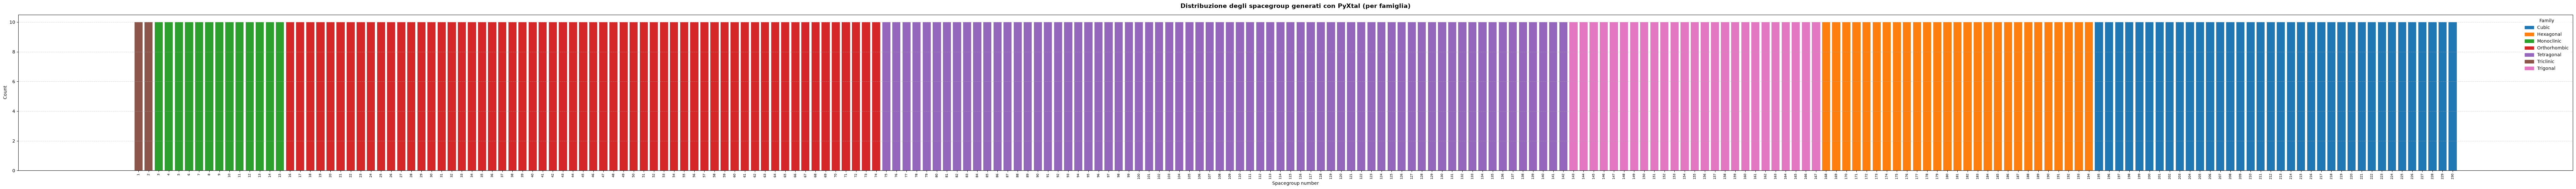

In [7]:
from dim_red.analysis.plotting import plot_spacegroup_histogram

spacegroups = [a.info["spacegroup"] for a in atoms_list]
plot_spacegroup_histogram(
    spacegroups,
    families,
    title="Distribuzione degli spacegroup generati con PyXtal (per famiglia)",
)

### (Bonus) SOAP + PCA sul dataset sintetico

Come per i dati scaricati da Materials Project, possiamo calcolare i descrittori SOAP e
ridurli con PCA per vedere come le famiglie cristalline si separano nello spazio ridotto.

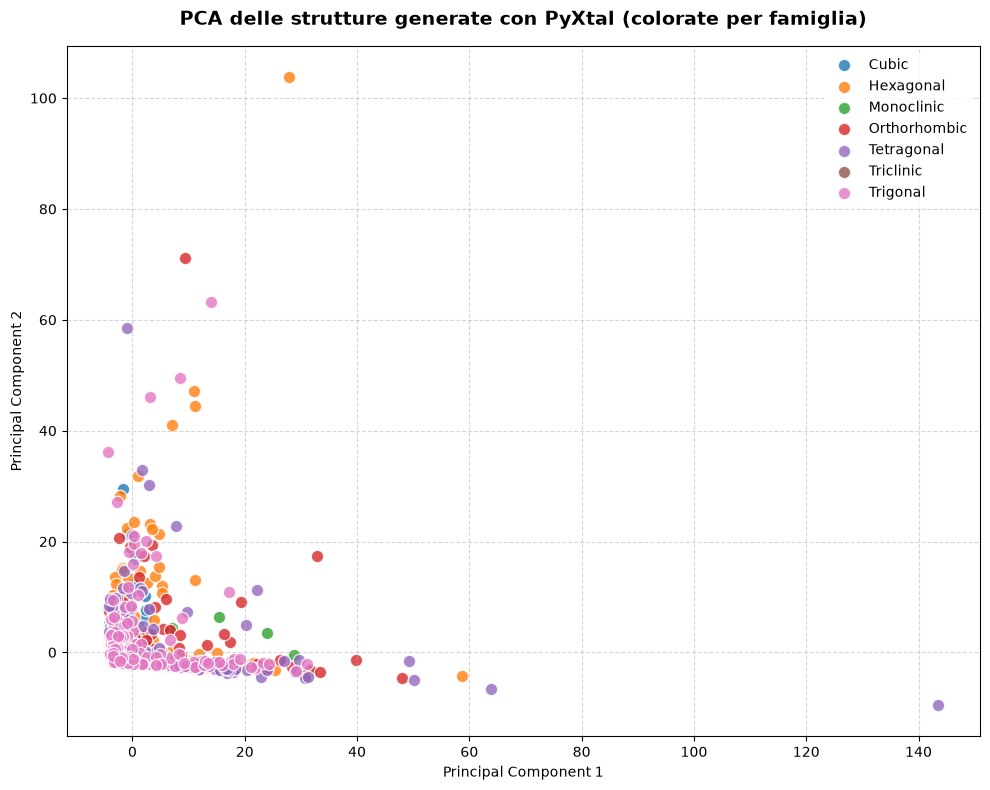

In [8]:
from dim_red.soap import compute_soap
from dim_red.utils import standardize
from dim_red.pca import PCA
from dim_red.analysis.plotting import plot_reduced_space

soap_vectors = compute_soap(atoms_list, r_cut=6.0, n_max=8, l_max=6, average="outer")
X_std = standardize(soap_vectors)

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_std)

plot_reduced_space(
    X_reduced,
    families,
    title="PCA delle strutture generate con PyXtal (colorate per famiglia)",
)

# Visualize

In [10]:
from ase.visualize import view

cubic_atoms = [a for a in atoms_list if a.info["spacegroup"] == 224]
view(cubic_atoms)

<Popen: returncode: None args: ['/home/seraftu/miniconda3/envs/dmred/bin/pyt...>